Non-Numeric Columns: Index(['Domain'], dtype='object')


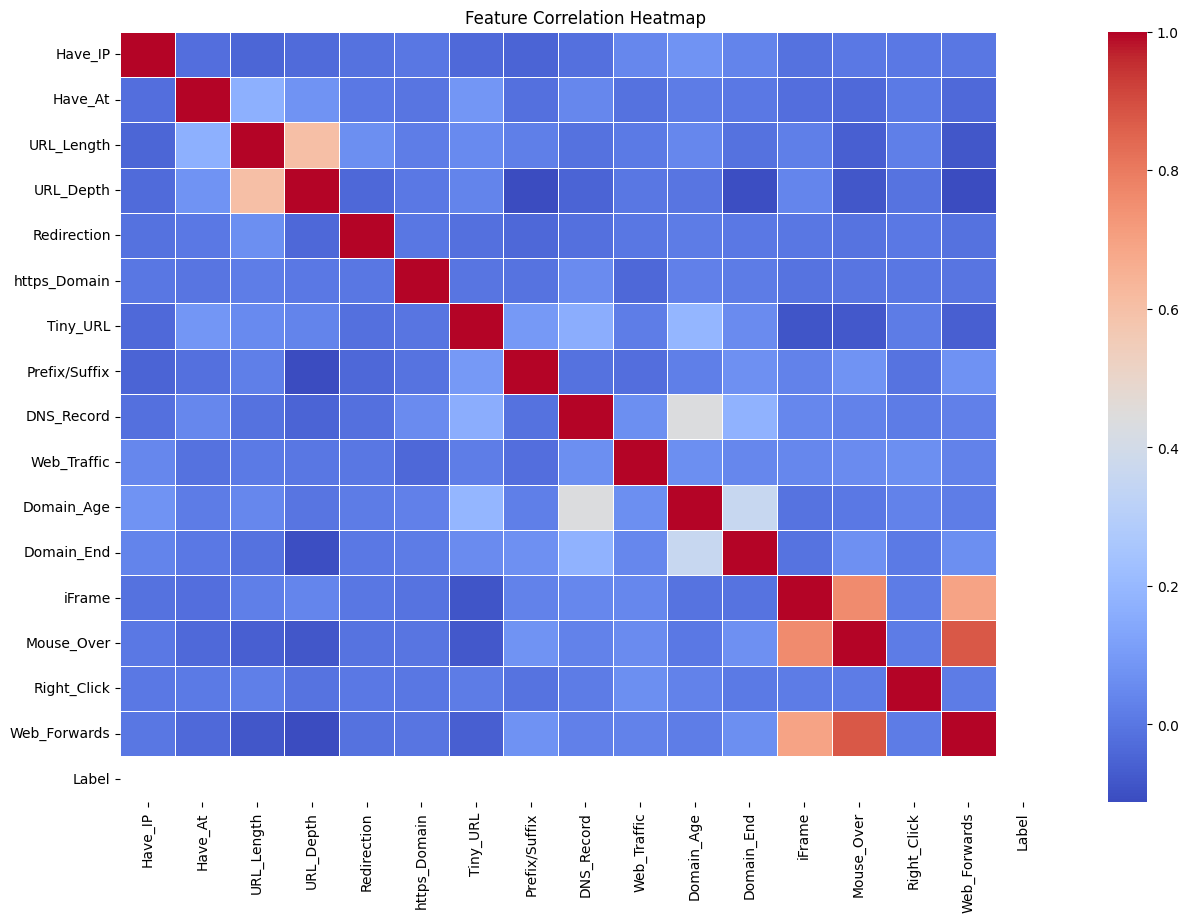

Dataset Columns: Index(['Domain', 'Have_IP', 'Have_At', 'URL_Length', 'URL_Depth',
       'Redirection', 'https_Domain', 'Tiny_URL', 'Prefix/Suffix',
       'DNS_Record', 'Web_Traffic', 'Domain_Age', 'Domain_End', 'iFrame',
       'Mouse_Over', 'Right_Click', 'Web_Forwards', 'Label'],
      dtype='object')
Feature Correlation with Target Variable:
 URL_Length       1.000000
URL_Depth        0.602714
Have_At          0.167909
Redirection      0.066366
Tiny_URL         0.052370
Domain_Age       0.042812
Prefix/Suffix    0.022529
iFrame           0.019972
Right_Click      0.019638
https_Domain     0.018212
Web_Traffic      0.006294
Domain_End      -0.013374
DNS_Record      -0.014596
Have_IP         -0.042656
Mouse_Over      -0.062531
Web_Forwards    -0.082008
Label                 NaN
Name: URL_Length, dtype: float64

Selected Features DataFrame:
    https_Domain  URL_Depth                   Domain  Redirection  \
0             0          4                 eevee.tv            0   
1      

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
file_path = "4.phishing (1).csv"  # Ensure the correct file path
df = pd.read_csv(file_path, encoding="ISO-8859-1")

# Check for non-numeric columns
non_numeric_cols = df.select_dtypes(exclude=['number']).columns
print("Non-Numeric Columns:", non_numeric_cols)

# Drop non-numeric columns before correlation analysis
df_numeric = df.drop(columns=non_numeric_cols, errors='ignore')

# Compute the correlation matrix
corr_matrix = df_numeric.corr()

# Plot the heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False, linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

# Confirm column names
print("Dataset Columns:", df.columns)

# Ensure target variable exists before computing correlation
target_variable = "URL_Length"  # Change if needed
if target_variable in corr_matrix.columns:
    target_corr = corr_matrix[target_variable].sort_values(ascending=False)
    print("Feature Correlation with Target Variable:\n", target_corr)
else:
    print(f"Error: '{target_variable}' column not found in correlation matrix!")

# Selecting the most correlated features for model training
selected_features = ["https_Domain", "URL_Depth", "Domain", "Redirection", "Prefix/Suffix"]
if all(feature in df.columns for feature in selected_features):
    df_selected = df[selected_features + [target_variable]].dropna()
    print("\nSelected Features DataFrame:\n", df_selected.head())
else:
    missing_features = [f for f in selected_features if f not in df.columns]
    print(f"Error: Missing features in dataset - {missing_features}")


Feature Data Types:
 https_Domain      int64
URL_Depth         int64
Domain           object
Redirection       int64
Prefix/Suffix     int64
dtype: object
Encoding categorical feature: Domain

Logistic Regression:
               precision    recall  f1-score   support

           0       0.74      0.80      0.77       466
           1       0.81      0.76      0.78       534

    accuracy                           0.78      1000
   macro avg       0.78      0.78      0.78      1000
weighted avg       0.78      0.78      0.78      1000


Random Forest:
               precision    recall  f1-score   support

           0       0.81      0.76      0.78       466
           1       0.80      0.84      0.82       534

    accuracy                           0.81      1000
   macro avg       0.81      0.80      0.80      1000
weighted avg       0.81      0.81      0.80      1000


Gradient Boosting:
               precision    recall  f1-score   support

           0       0.76      0.79     

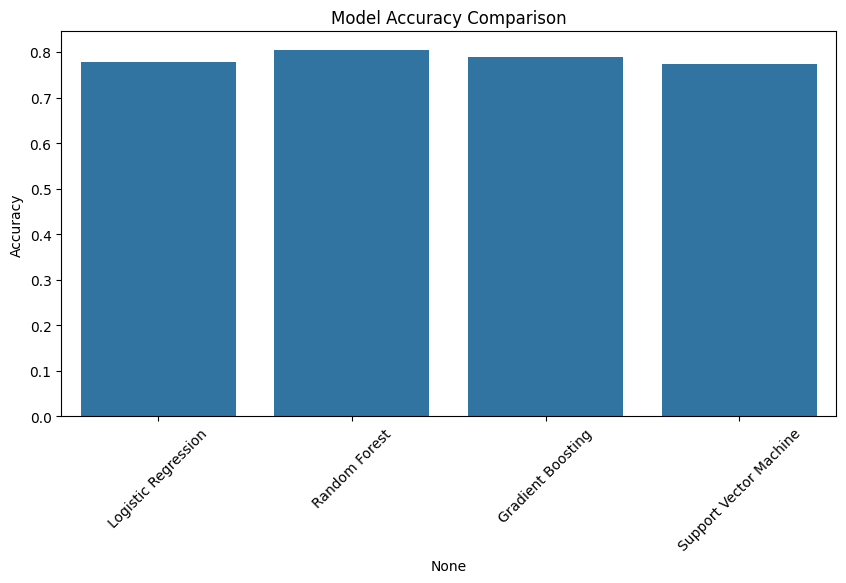

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Load dataset
file_path = "4.phishing (1).csv"  # Ensure correct file path
df = pd.read_csv(file_path, encoding="ISO-8859-1")

# Selecting target and features
target = "URL_Length"  # Change if needed
selected_features = ["https_Domain", "URL_Depth", "Domain", "Redirection", "Prefix/Suffix"]

# Check data types of selected features
print("Feature Data Types:\n", df[selected_features].dtypes)

# Convert non-numeric features to numeric (Categorical Encoding)
for feature in selected_features:
    if df[feature].dtype == 'object':  # If it's a string
        print(f"Encoding categorical feature: {feature}")
        df[feature] = LabelEncoder().fit_transform(df[feature].astype(str))

# Drop missing values
df = df.dropna(subset=selected_features + [target])

# Splitting dataset into features (X) and target (y)
X = df[selected_features]
y = df[target]

# Standardizing numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data into train (80%) and test (20%)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Define models
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Support Vector Machine": SVC(probability=True, random_state=42)
}

# Train and evaluate models
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    results[name] = {"Accuracy": accuracy, "AUC-ROC": auc}
    print(f"\n{name}:\n", classification_report(y_test, y_pred))

# Compare models
results_df = pd.DataFrame(results).T
print("\nModel Performance Comparison:\n", results_df)

# Plot performance comparison
plt.figure(figsize=(10, 5))
sns.barplot(x=results_df.index, y=results_df["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.show()


Encoding categorical feature: Domain

Logistic Regression:
               precision    recall  f1-score   support

           0       0.74      0.80      0.77       466
           1       0.81      0.76      0.78       534

    accuracy                           0.78      1000
   macro avg       0.78      0.78      0.78      1000
weighted avg       0.78      0.78      0.78      1000


Random Forest:
               precision    recall  f1-score   support

           0       0.81      0.76      0.78       466
           1       0.80      0.84      0.82       534

    accuracy                           0.81      1000
   macro avg       0.81      0.80      0.80      1000
weighted avg       0.81      0.81      0.80      1000


Gradient Boosting:
               precision    recall  f1-score   support

           0       0.76      0.79      0.78       466
           1       0.81      0.79      0.80       534

    accuracy                           0.79      1000
   macro avg       0.79      0

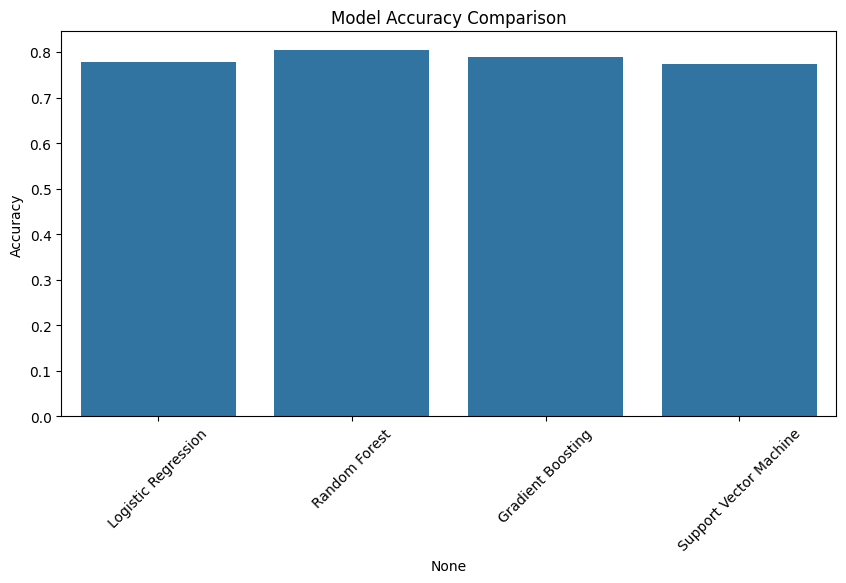

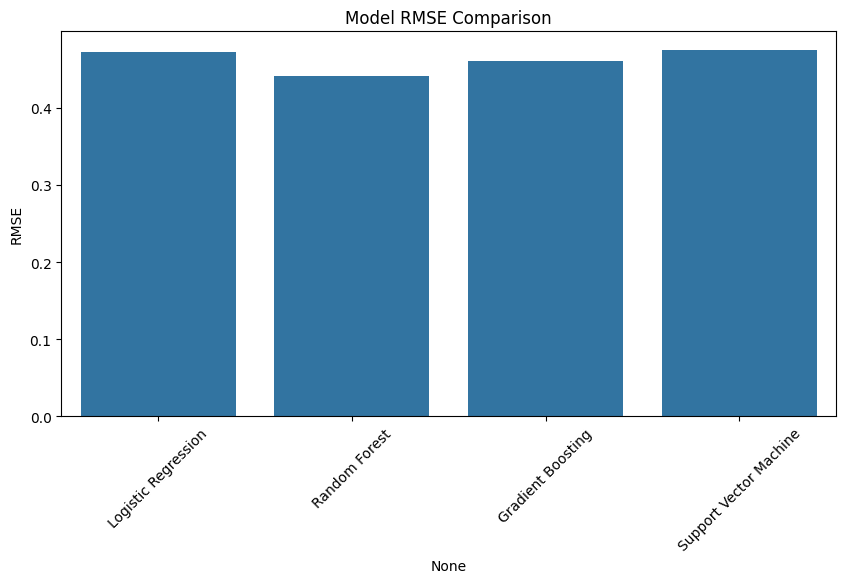

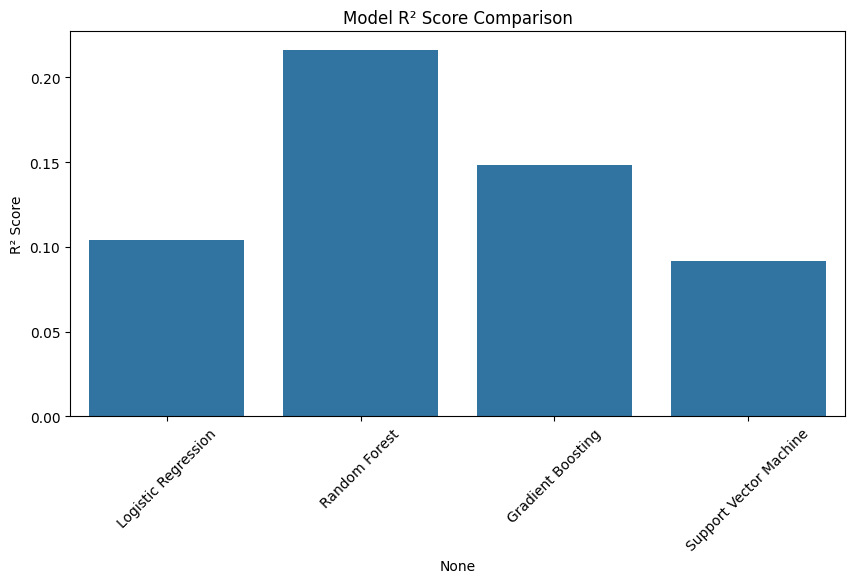

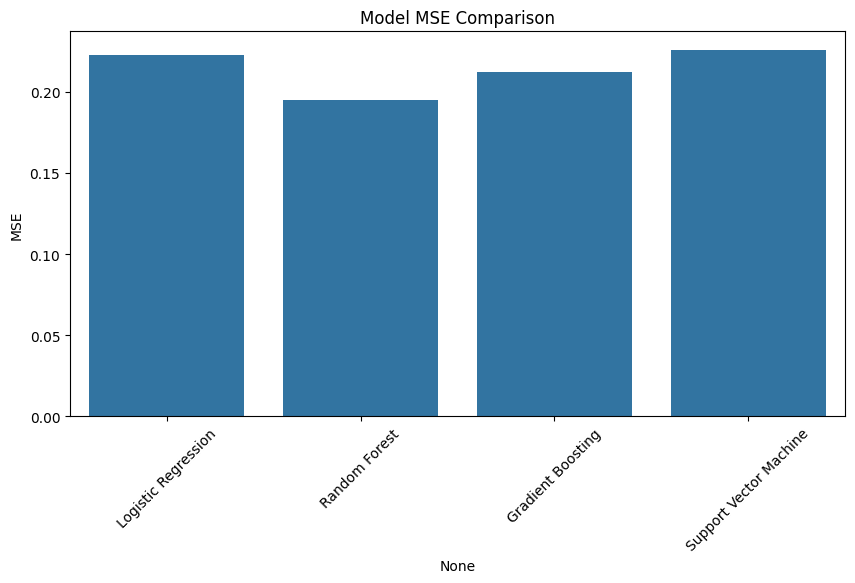

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, roc_auc_score, 
    mean_squared_error, mean_absolute_error, r2_score
)

# Load dataset
file_path = "4.phishing (1).csv"  # Ensure correct file path
df = pd.read_csv(file_path, encoding="ISO-8859-1")

# Selecting target and features
target = "URL_Length"  # Change if needed
selected_features = ["https_Domain", "URL_Depth", "Domain", "Redirection", "Prefix/Suffix"]

# Convert non-numeric features to numeric (Categorical Encoding)
for feature in selected_features:
    if df[feature].dtype == 'object':  # If it's a string
        print(f"Encoding categorical feature: {feature}")
        df[feature] = LabelEncoder().fit_transform(df[feature].astype(str))

# Drop missing values
df = df.dropna(subset=selected_features + [target])

# Splitting dataset into features (X) and target (y)
X = df[selected_features]
y = df[target]

# Standardizing numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data into train (80%) and test (20%)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Define models
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Support Vector Machine": SVC(probability=True, random_state=42)
}

# Train and evaluate models
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Calculate error metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

    results[name] = {
        "Accuracy": accuracy,
        "AUC-ROC": auc,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R² Score": r2
    }

    print(f"\n{name}:\n", classification_report(y_test, y_pred))

# Compare models
results_df = pd.DataFrame(results).T
print("\nModel Performance Comparison:\n", results_df)

# Plot accuracy comparison
plt.figure(figsize=(10, 5))
sns.barplot(x=results_df.index, y=results_df["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.show()

# Plot RMSE comparison
plt.figure(figsize=(10, 5))
sns.barplot(x=results_df.index, y=results_df["RMSE"])
plt.title("Model RMSE Comparison")
plt.ylabel("RMSE")
plt.xticks(rotation=45)
plt.show()

# Plot RMSE comparison
plt.figure(figsize=(10, 5))
sns.barplot(x=results_df.index, y=results_df["R² Score"])
plt.title("Model R² Score Comparison")
plt.ylabel("R² Score")
plt.xticks(rotation=45)
plt.show()

# Plot RMSE comparison
plt.figure(figsize=(10, 5))
sns.barplot(x=results_df.index, y=results_df["MSE"])
plt.title("Model MSE Comparison")
plt.ylabel("MSE")
plt.xticks(rotation=45)
plt.show()